In [1]:
%%html

<style>
    .container-fluid.main-container {
        margin-left: 3em;
        margin-right: 8em;
        max-width: 100vw;
    }
</style>

# Introduction

This notebook contains an application of the GVS propagator to computer-generated holography. We use GVS to calculate the forward propagation of light emitted by a common mobile phone screen and reflected by a phase-only spatial light modulator at various propagation distances. Then we optimize for four image channels (RGB and phase) using stochastic gradient descent with Adam in Pytorch to obtain the intensity and phase holograms that produce the desired images at different depths.

<center><img alt="Experimental Setup" src="img/experimental-setup.png" width="512"/></center>

In [2]:
import numpy as np
import torch

from imageio.v3 import imread
from torchvision.transforms import CenterCrop

from gvs_propagator.cgh.rgb_asm import solve_inverse_problem, forward_model
from gvs_propagator.utils import create_grid, normalize
from gvs_propagator.constants import nm, um, mm
from gvs_propagator.notebooks.utils import display_image

# Physical and numerical parameters

In [3]:
device = "mps"  # Use cuda or cpu depending on installation
nx_source = 256
nx_slm = ny_slm = 512
nx_camera = ny_camera = 256
dx_source = 55.2 * um
dx_object = 3.74 * um

red = 620 * nm
green = 532 * nm
blue = 461 * nm
reference_wavelength = 520 * nm
wavelengths = [red, green, blue]

z_source_object = 250 * mm
z_object_camera_1 = 80 * mm
z_object_camera_2 = 100 * mm
propagation_distances = [z_object_camera_1, z_object_camera_2]
image_paths = ["img/peppers.png", "img/baboon.png"]

nx_source_numerical = [
    round(z / z_source_object * dx_source / dx_object * nx_source)
    for z in propagation_distances
]

x, y = create_grid(nx_slm * 2, dx_object, ny_slm * 2)
phase_factors = [
    np.exp(1j * np.pi / red * (1 / z_source_object) * (x ** 2 + y ** 2)),
    np.exp(1j * np.pi / green * (1 / z_source_object) * (x ** 2 + y ** 2)),
    np.exp(1j * np.pi / blue * (1 / z_source_object) * (x ** 2 + y ** 2))
]

# Target images

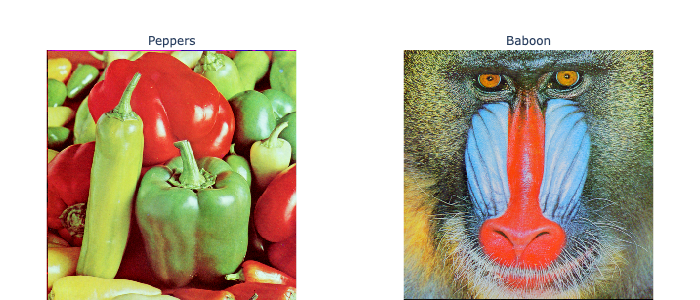

In [4]:
display_image(
    field=[imread(i) for i in image_paths],
    show_as_grid=True,
    normalize_all_frames=True,
    grid_titles=["Peppers", "Baboon"],
)

# CGH optimization

In [5]:
source, phase = solve_inverse_problem(
    image_paths,
    nx_source,
    nx_source_numerical,
    phase_factors,
    propagation_distances,
    dx_object,
    wavelengths,
    reference_wavelength,
    nx_slm,
    ny_slm,
    nx_camera,
    ny_camera,
    lr=0.05,
    iterations=200,
    device=device,
    batch_size=2,
)

  0%|          | 0/200 [00:00<?, ?it/s]

# Optimized intensity hologram

Displayed on the mobile phone.

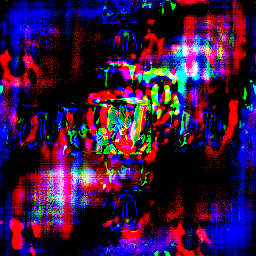

In [6]:
display_image(
    source,
    normalize_all_frames=True,
    height=nx_source,
    width=nx_source
)

# Optimized phase hologram

Displayed on the SLM.

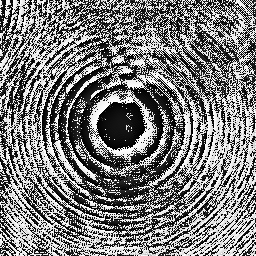

In [7]:
display_image(
    np.mod(phase, 2 * np.pi),
    height=nx_source,
    width=nx_source
)

# Numerical reconstructions after optimization

In [8]:
max_intensities = []
results = []
psnr_list = []
for j in range(len(propagation_distances)):
    rgb = []
    for k in range(3):
        result = forward_model(
            torch.tensor(source[:, :, k], device=device),
            CenterCrop([ny_slm * 2, nx_slm * 2])(torch.tensor(phase, device=device)),
            torch.tensor(phase_factors[k], device=device, dtype=torch.complex64),
            nx_source_numerical[j],
            propagation_distances[j],
            dx_object,
            wavelengths[k],
            reference_wavelength,
            device=device,
        )
        if j == 0:
            max_intensities.append(result.max())
        result = CenterCrop([ny_camera, nx_camera])(result / max_intensities[k])
        rgb.append(result.cpu().numpy())

    estimated_image = np.stack(rgb, axis=-1)
    results.append(estimated_image)

    mse = np.mean((normalize(estimated_image) - normalize(imread(image_paths[j]))) ** 2)
    psnr = 10 * np.log10(1 / mse)
    psnr_list.append(psnr)

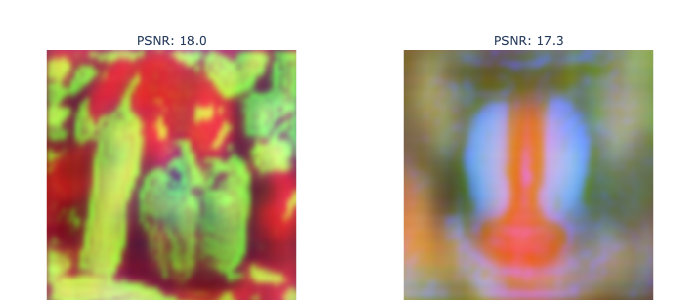

In [9]:
display_image(
    results,
    show_as_grid=True,
    normalize_all_frames=True,
    grid_titles=[f"PSNR: {round(psnr, 1)}" for psnr in psnr_list],
)